In [1]:
%matplotlib inline

In [2]:
import os
import json
import time
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)

In [5]:
from xgboost import XGBRegressor

In [6]:
RANDOM_STATE = 42
USE_GPU = True
N_COMPONENTS = 20  # fixed, from prior PCA-dimensionality ablation

In [7]:
# ---- 0. Paths ----
DATA_DIR = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset"
TRAIN_FILE = f"{DATA_DIR}/ML_train.csv"
TEST_FILE = f"{DATA_DIR}/ML_test.csv"
BERT_FILE = r"E:\NSU\cse445\EDA attempt3\NLP models\embeddings\bert_embeddings.csv"

In [8]:
# ---- 1. BayesSearchCV optimum (from bert_xgb_bayes_best_params.json) ----
BEST_PARAMS = {
    "colsample_bytree": 0.9512165066659852,
    "learning_rate": 0.07643904937766527,
    "max_depth": 6,
    "min_child_weight": 7,
    "n_estimators": 459,
    "reg_alpha": 0.0014729254229045347,
    "reg_lambda": 0.845771345696438,
    "subsample": 0.8060762192885254,
}

In [9]:
# ---- 2. Load data ----
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)
bert_raw = pd.read_csv(BERT_FILE)

In [10]:
TARGET_RAW = "target_usd"
TARGET_LOG = "log_target"
DROP_FROM_X = ["id", "target_usd", "log_target", "goal_usd"]

In [11]:
train_ids = set(train_df["id"])
feature_cols = [c for c in bert_raw.columns if c != "id"]
train_mask = bert_raw["id"].isin(train_ids)

In [12]:
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(bert_raw.loc[train_mask, feature_cols])
reduced_all = pca.transform(bert_raw[feature_cols])
reduced_cols = [f"bert_pca_{i}" for i in range(N_COMPONENTS)]
reduced_df = pd.DataFrame(reduced_all, columns=reduced_cols)
reduced_df.insert(0, "id", bert_raw["id"].values)

In [13]:
merged_train = train_df.merge(reduced_df, on="id", how="left")
merged_test = test_df.merge(reduced_df, on="id", how="left")

In [14]:
X_train = merged_train.drop(columns=DROP_FROM_X, errors="ignore")
X_test = merged_test.drop(columns=DROP_FROM_X, errors="ignore")
y_train = merged_train[TARGET_LOG].copy()
y_test = merged_test[TARGET_LOG].copy()
actual_usd = merged_test[TARGET_RAW].to_numpy()

In [15]:
assert list(X_train.columns) == list(X_test.columns)
print(f"Feature count: {X_train.shape[1]}")

Feature count: 97


In [16]:
# ---- 3. Evaluation helper ----
def evaluate_model(y_true_log, pred_log, actual_usd):
    pred_usd = np.expm1(pred_log)
    pred_usd = np.clip(pred_usd, a_min=0, a_max=None)

    rmse_log = np.sqrt(mean_squared_error(y_true_log, pred_log))
    r2_log = r2_score(y_true_log, pred_log)
    r2_usd = r2_score(actual_usd, pred_usd)
    rmsle = np.sqrt(mean_squared_log_error(actual_usd, pred_usd))

    return {"RMSE_log": rmse_log, "R2_log": r2_log, "R2_USD": r2_usd, "RMSLE": rmsle}

In [17]:
def fit_and_eval(param_overrides):
    params = dict(BEST_PARAMS)
    params.update(param_overrides)

    model = XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse",
        tree_method="hist", device="cuda" if USE_GPU else "cpu",
        random_state=RANDOM_STATE,
        **params,
    )
    model.fit(X_train, y_train)
    pred_log = model.predict(X_test)
    return evaluate_model(y_test, pred_log, actual_usd)

In [18]:
# ---- 4. Sweep ranges (centered on BayesSearchCV optimum) ----
SWEEPS = {
    "n_estimators":  [200, 300, 400, 459, 500, 600, 700],
    "max_depth":     [3, 4, 5, 6, 7, 8, 9],
    "learning_rate": [0.01, 0.03, 0.05, 0.0764, 0.09, 0.1, 0.12],
}

In [19]:
all_results = {}

In [20]:
for param_name, values in SWEEPS.items():
    print(f"\n{'='*70}")
    print(f"SWEEPING: {param_name}")
    print(f"{'='*70}")

    rows = []
    for v in values:
        start = time.time()
        metrics = fit_and_eval({param_name: v})
        elapsed = time.time() - start
        metrics[param_name] = v
        metrics["Time_Seconds"] = elapsed
        rows.append(metrics)
        print(f"{param_name}={v}: RMSLE={metrics['RMSLE']:.4f} | "
              f"R2_log={metrics['R2_log']:.4f} | R2_USD={metrics['R2_USD']:.4f} | "
              f"time={elapsed:.1f}s")

    df_result = pd.DataFrame(rows)
    all_results[param_name] = df_result
    df_result.to_csv(f"sensitivity_{param_name}.csv", index=False)
    print(f"Saved: sensitivity_{param_name}.csv")


SWEEPING: n_estimators
n_estimators=200: RMSLE=1.6020 | R2_log=0.7264 | R2_USD=0.1245 | time=1.3s
n_estimators=300: RMSLE=1.5449 | R2_log=0.7454 | R2_USD=0.1469 | time=1.4s
n_estimators=400: RMSLE=1.5167 | R2_log=0.7545 | R2_USD=0.1675 | time=1.8s
n_estimators=459: RMSLE=1.5065 | R2_log=0.7578 | R2_USD=0.1769 | time=2.6s
n_estimators=500: RMSLE=1.5011 | R2_log=0.7595 | R2_USD=0.1773 | time=2.7s
n_estimators=600: RMSLE=1.4871 | R2_log=0.7639 | R2_USD=0.1849 | time=3.4s
n_estimators=700: RMSLE=1.4800 | R2_log=0.7661 | R2_USD=0.1899 | time=3.2s
Saved: sensitivity_n_estimators.csv

SWEEPING: max_depth
max_depth=3: RMSLE=1.6469 | R2_log=0.7107 | R2_USD=0.0871 | time=1.3s
max_depth=4: RMSLE=1.5517 | R2_log=0.7430 | R2_USD=0.1352 | time=2.4s
max_depth=5: RMSLE=1.5108 | R2_log=0.7564 | R2_USD=0.1557 | time=2.1s
max_depth=6: RMSLE=1.5065 | R2_log=0.7578 | R2_USD=0.1769 | time=2.2s
max_depth=7: RMSLE=1.5203 | R2_log=0.7533 | R2_USD=0.1417 | time=3.5s
max_depth=8: RMSLE=1.5529 | R2_log=0.7428 | 

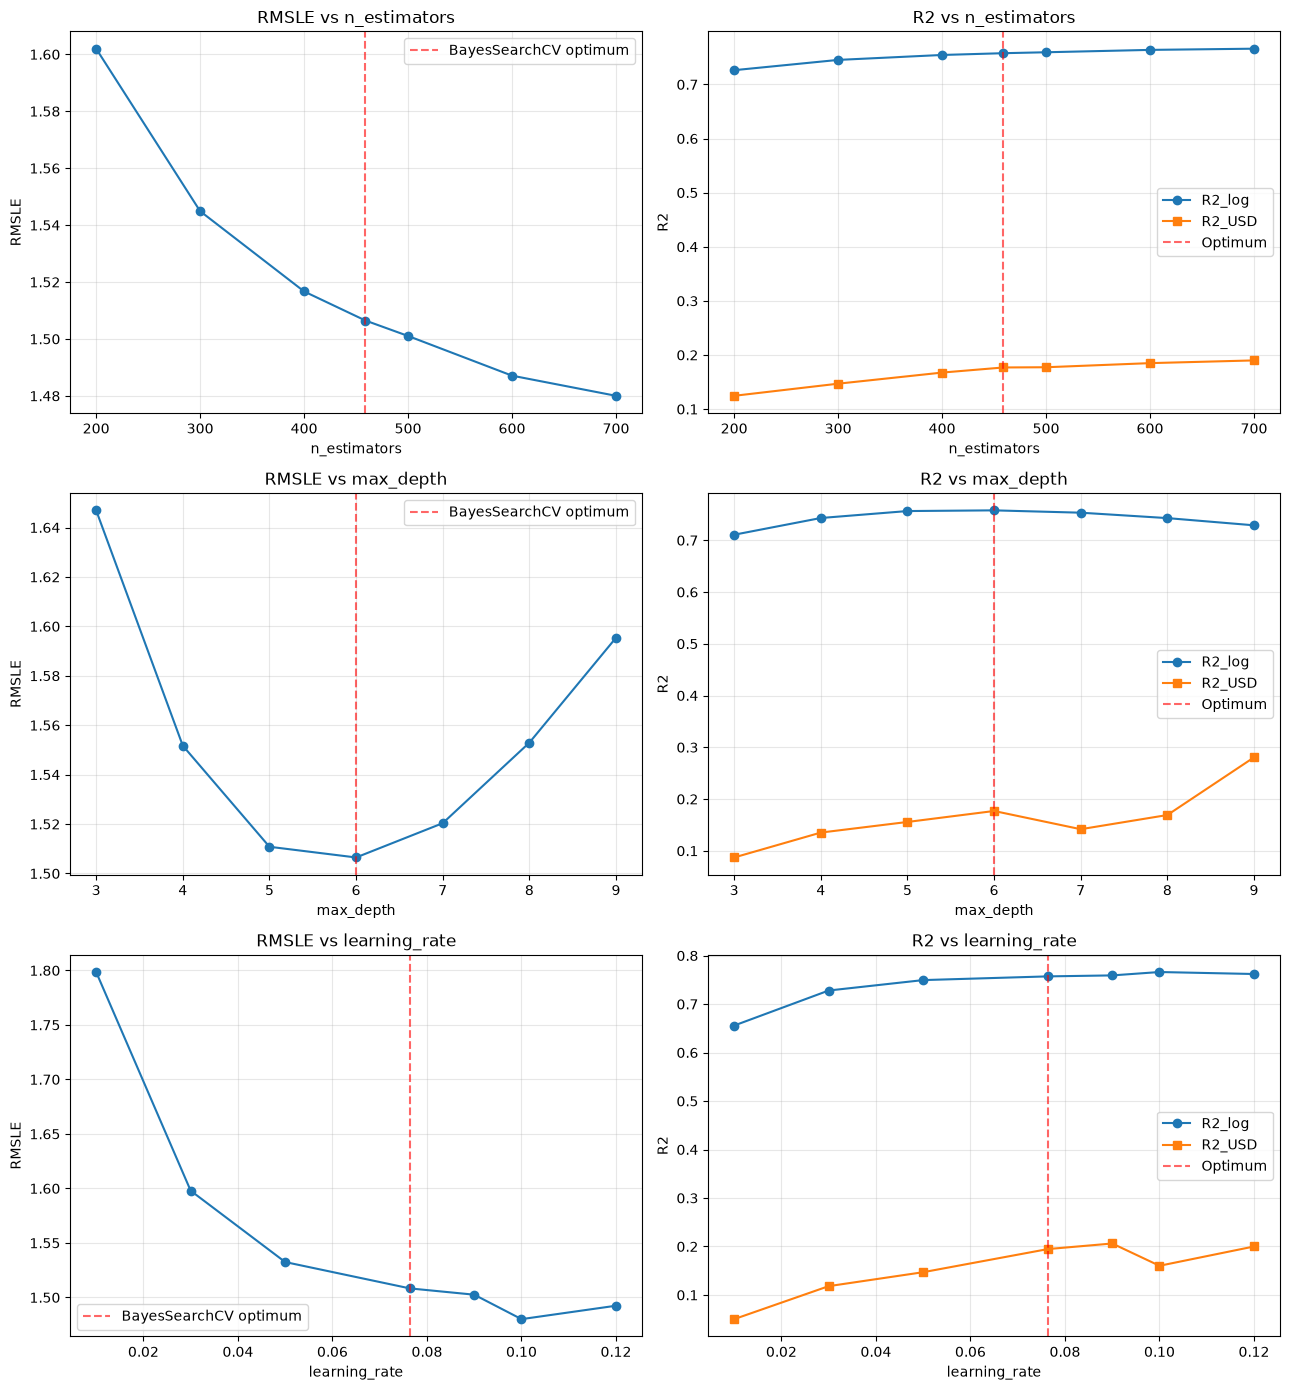


Saved: xgb_sensitivity_curves.png


In [24]:
# ---- 5. Plot sensitivity curves ----
fig, axes = plt.subplots(3, 2, figsize=(13, 14))
for i, (param_name, df_result) in enumerate(all_results.items()):
    optimum_val = BEST_PARAMS[param_name]

    axes[i, 0].plot(df_result[param_name], df_result["RMSLE"], marker="o")
    axes[i, 0].axvline(optimum_val, color="red", linestyle="--", alpha=0.6, label="BayesSearchCV optimum")
    axes[i, 0].set_xlabel(param_name)
    axes[i, 0].set_ylabel("RMSLE")
    axes[i, 0].set_title(f"RMSLE vs {param_name}")
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(df_result[param_name], df_result["R2_log"], marker="o", label="R2_log")
    axes[i, 1].plot(df_result[param_name], df_result["R2_USD"], marker="s", label="R2_USD")
    axes[i, 1].axvline(optimum_val, color="red", linestyle="--", alpha=0.6, label="Optimum")
    axes[i, 1].set_xlabel(param_name)
    axes[i, 1].set_ylabel("R2")
    axes[i, 1].set_title(f"R2 vs {param_name}")
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)
    plt.tight_layout()
plt.savefig("xgb_sensitivity_curves.png", dpi=150)
plt.show()
print("\nSaved: xgb_sensitivity_curves.png")